In [ ]:
# Run this cell once if the libraries are not installed
!pip install tensorflow numpy matplotlib
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"

path = tf.keras.utils.get_file(
    "tinyshakespeare.txt",
    origin=url
)

with open(path, "r", encoding="utf-8") as file:
    text = file.read()

# Use a smaller portion so training is manageable in a notebook
text = text[:100000]

print("Number of characters:", len(text))
print("\nFirst 500 characters:\n")
print(text[:500])

1115394/1115394 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Number of characters: 100000

First 500 characters:

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


In [ ]:
vocab = sorted(set(text))

char_to_id = {
    char: index
    for index, char in enumerate(vocab)
}

id_to_char = np.array(vocab)

encoded_text = np.array(
    [char_to_id[char] for char in text],
    dtype=np.int32
)

print("Vocabulary size:", len(vocab))
print("Vocabulary:")
print("".join(vocab))

Vocabulary size: 61
Vocabulary:

 !&',-.:;?ABCDEFGHIJKLMNOPQRSTUVWYabcdefghijklmnopqrstuvwxyz


In [ ]:
sequence_length = 100
batch_size = 64

dataset = tf.data.Dataset.from_tensor_slices(encoded_text)

sequences = dataset.batch(
    sequence_length + 1,
    drop_remainder=True
)

def split_input_target(sequence):
    input_text = sequence[:-1]
    target_text = sequence[1:]

    return input_text, target_text

sequences = sequences.map(split_input_target)

sequences = sequences.shuffle(10000)
sequences = sequences.batch(
    batch_size,
    drop_remainder=True
)

sequences = sequences.prefetch(tf.data.AUTOTUNE)

print("Training sequences are ready.")

Training sequences are ready.


In [ ]:
vocab_size = len(vocab)

model = models.Sequential([
    layers.Embedding(
        input_dim=vocab_size,
        output_dim=128
    ),

    layers.LSTM(
        256,
        return_sequences=True
    ),

    layers.Dense(vocab_size)
])

loss = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True
)

model.compile(
    optimizer="adam",
    loss=loss
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# You can increase this to 20 or more for better text.
epochs = 10

history = model.fit(
    sequences,
    epochs=epochs
)

Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 500ms/step - loss: 3.6584
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 538ms/step - loss: 3.2496
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 444ms/step - loss: 3.0213
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 465ms/step - loss: 2.7477
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 535ms/step - loss: 2.5556
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 546ms/step - loss: 2.4412
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 444ms/step - loss: 2.3567
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 452ms/step - loss: 2.2890
Epoch 9/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 545ms/step - loss: 2.2334
Epoch 10/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 451ms/step - loss: 2.1826


In [ ]:
def generate_text(
    model,
    start_string,
    num_generate=500,
    temperature=0.8
):

    generated = list(start_string)

    for _ in range(num_generate):

        # Use the most recent characters as context
        context = generated[-sequence_length:]

        input_ids = [
            char_to_id.get(char, 0)
            for char in context
        ]

        input_ids = tf.expand_dims(
            input_ids,
            0
        )

        predictions = model(input_ids)

        # Get prediction for the last character
        predictions = predictions[:, -1, :]

        # Apply temperature
        predictions = predictions / temperature

        # Randomly select the next character
        next_id = tf.random.categorical(
            predictions,
            num_samples=1
        )[0, 0].numpy()

        generated.append(
            id_to_char[next_id]
        )

    return "".join(generated)

In [8]:
print("Temperature = 0.2")
print(generate_text(
    model,
    "ROMEO:",
    num_generate=300,
    temperature=0.2
))

print("\n" + "=" * 80)

print("Temperature = 0.8")
print(generate_text(
    model,
    "ROMEO:",
    num_generate=300,
    temperature=0.8
))

print("\n" + "=" * 80)

print("Temperature = 1.2")
print(generate_text(
    model,
    "ROMEO:",
    num_generate=300,
    temperature=1.2
))

Temperature = 0.2
ROMEO:
Whe the the wor the me the the the the the and the prath the the the the the the meat the math me the gour the the the math the he the sore the the the me the sore the the the the mathe he the the the the me sore the me the mad the he the the the the the the he the he the the the he the the the the

Temperature = 0.8
ROMEO:
The recand vacein ceoll selcat to beors, the your as mage Cantirf, I Coretos the thar whants ley an bey oge the he one basn ande he pamet
an uncou, kethe wort anth to th any
The hase ind wit an
Wha coro as of you hereesesinith w sonithead 'y thercin ulef
ho for goure.

BRUTI
S:
Mirt,
You sindent ta

Temperature = 1.2
ROMEO:
BCWeqes af tot nequk kered is tiunegis trucully theo.

BTECUONIodt
RNoos gool fe iod,
If catghode ufd whio pe bras, &rith Cioor.
Cyot wnemeg?

VENIAs:
Iy dees jowhind re es wad es iurdy sheime!
nomt lut,
Fid nole pom eav't''g, I hals wuar dowke
Cithith an ome if motes's byti, Cocheruve goster-
og o


In [9]:
print("""
Temperature controls the randomness of text generation.

A low temperature such as 0.2 makes the model more predictable.
The model strongly prefers characters with high probability.

A temperature around 0.8 provides a balance between predictability
and randomness.

A high temperature such as 1.2 increases randomness. This can create
more varied text, but the generated text can also become less coherent.
""")


Temperature controls the randomness of text generation.

A low temperature such as 0.2 makes the model more predictable.
The model strongly prefers characters with high probability.

A temperature around 0.8 provides a balance between predictability
and randomness.

A high temperature such as 1.2 increases randomness. This can create
more varied text, but the generated text can also become less coherent.



In [10]:
!pip install tensorflow scikit-learn matplotlib
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

np.random.seed(42)
tf.random.set_seed(42)

In [11]:
num_words = 10000

(x_train, y_train), (x_test, y_test) = imdb.load_data(
    num_words=num_words
)

print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))

print("\nFirst review:")
print(x_train[0])

print("\nFirst label:")
print(y_train[0])

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000
Testing samples: 25000

First review:
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5

In [12]:
max_length = 200

x_train = pad_sequences(
    x_train,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

x_test = pad_sequences(
    x_test,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)

Training shape: (25000, 200)
Testing shape: (25000, 200)


In [13]:
model = models.Sequential([

    layers.Embedding(
        input_dim=num_words,
        output_dim=128,
        input_length=max_length
    ),

    layers.LSTM(64),

    layers.Dropout(0.5),

    layers.Dense(
        1,
        activation="sigmoid"
    )
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 370ms/step - accuracy: 0.5185 - loss: 0.6938 - val_accuracy: 0.5036 - val_loss: 0.6956
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 381ms/step - accuracy: 0.5633 - loss: 0.6921 - val_accuracy: 0.5402 - val_loss: 0.6787
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 58s 371ms/step - accuracy: 0.5471 - loss: 0.6945 - val_accuracy: 0.5400 - val_loss: 0.6853
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 83s 378ms/step - accuracy: 0.5339 - loss: 0.6853 - val_accuracy: 0.5404 - val_loss: 0.6831
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 82s 377ms/step - accuracy: 0.5803 - loss: 0.6584 - val_accuracy: 0.5852 - val_loss: 0.6487


In [15]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.6604546308517456
Test Accuracy: 0.5685200095176697


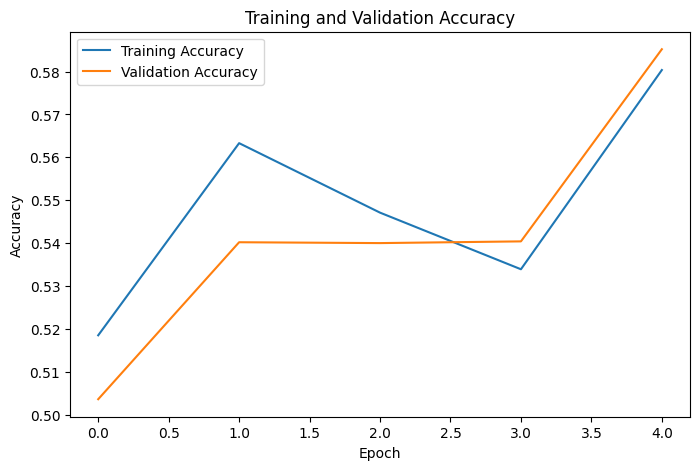

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.show()

In [17]:
probabilities = model.predict(
    x_test,
    verbose=0
).ravel()

y_pred = (probabilities >= 0.5).astype(int)

cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Negative",
            "Positive"
        ],
        digits=4
    )
)

Confusion Matrix:
[[10942  1558]
 [ 9229  3271]]

Classification Report:
              precision    recall  f1-score   support

    Negative     0.5425    0.8754    0.6698     12500
    Positive     0.6774    0.2617    0.3775     12500

    accuracy                         0.5685     25000
   macro avg     0.6099    0.5685    0.5237     25000
weighted avg     0.6099    0.5685    0.5237     25000



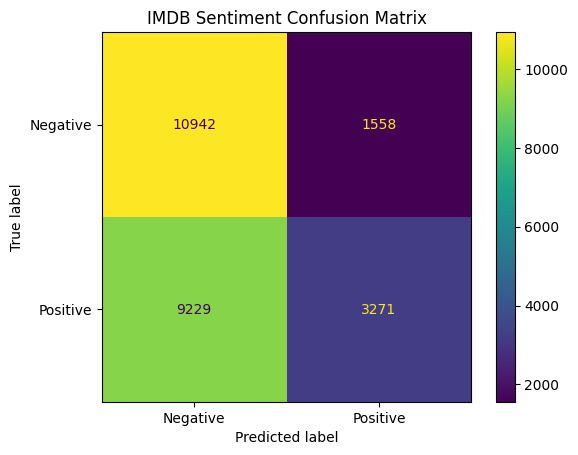

In [18]:
display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Negative",
        "Positive"
    ]
)

display.plot()

plt.title("IMDB Sentiment Confusion Matrix")
plt.show()

In [19]:
print("""
Precision tells us how many of the reviews predicted as positive
were actually positive.

Recall tells us how many of the actual positive reviews were
correctly identified by the model.

There is a tradeoff between precision and recall because changing
the classification threshold can change the number of false
positives and false negatives.

For sentiment classification, the balance depends on the purpose
of the application.
""")


Precision tells us how many of the reviews predicted as positive
were actually positive.

Recall tells us how many of the actual positive reviews were
correctly identified by the model.

There is a tradeoff between precision and recall because changing
the classification threshold can change the number of false
positives and false negatives.

For sentiment classification, the balance depends on the purpose
of the application.



In [21]:
import numpy as np
import tensorflow as tf
input_matrix = np.array([
    [1,  2,  3,  4,  5],
    [6,  7,  8,  9, 10],
    [11, 12, 13, 14, 15],
    [16, 17, 18, 19, 20],
    [21, 22, 23, 24, 25]
], dtype=np.float32)

kernel = np.array([
    [0,  1,  0],
    [1, -4,  1],
    [0,  1,  0]
], dtype=np.float32)

print("Input Matrix:")
print(input_matrix)

print("\nKernel:")
print(kernel)


Input Matrix:
[[ 1.  2.  3.  4.  5.]
 [ 6.  7.  8.  9. 10.]
 [11. 12. 13. 14. 15.]
 [16. 17. 18. 19. 20.]
 [21. 22. 23. 24. 25.]]

Kernel:
[[ 0.  1.  0.]
 [ 1. -4.  1.]
 [ 0.  1.  0.]]


In [22]:
def perform_convolution(stride, padding):

    input_tensor = input_matrix.reshape(
        1, 5, 5, 1
    )

    kernel_tensor = kernel.reshape(
        3, 3, 1, 1
    )

    output = tf.nn.conv2d(
        input_tensor,
        kernel_tensor,
        strides=[1, stride, stride, 1],
        padding=padding
    )

    return output.numpy().squeeze()


In [23]:
    result_1 = perform_convolution(
    stride=1,
    padding="VALID"
)

result_2 = perform_convolution(
    stride=1,
    padding="SAME"
)

result_3 = perform_convolution(
    stride=2,
    padding="VALID"
)

result_4 = perform_convolution(
    stride=2,
    padding="SAME"
)

print("Stride = 1, Padding = VALID")
print(result_1)

print("\nStride = 1, Padding = SAME")
print(result_2)

print("\nStride = 2, Padding = VALID")
print(result_3)

print("\nStride = 2, Padding = SAME")
print(result_4)


Stride = 1, Padding = VALID
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]

Stride = 1, Padding = SAME
[[  4.   3.   2.   1.  -6.]
 [ -5.   0.   0.   0. -11.]
 [-10.   0.   0.   0. -16.]
 [-15.   0.   0.   0. -21.]
 [-46. -27. -28. -29. -56.]]

Stride = 2, Padding = VALID
[[0. 0.]
 [0. 0.]]

Stride = 2, Padding = SAME
[[  4.   2.  -6.]
 [-10.   0. -16.]
 [-46. -28. -56.]]


In [24]:
results = {
    "Stride 1 - VALID": result_1,
    "Stride 1 - SAME": result_2,
    "Stride 2 - VALID": result_3,
    "Stride 2 - SAME": result_4
}

for name, result in results.items():
    print("\n" + "=" * 50)
    print(name)
    print("=" * 50)
    print(result)


Stride 1 - VALID
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]

Stride 1 - SAME
[[  4.   3.   2.   1.  -6.]
 [ -5.   0.   0.   0. -11.]
 [-10.   0.   0.   0. -16.]
 [-15.   0.   0.   0. -21.]
 [-46. -27. -28. -29. -56.]]

Stride 2 - VALID
[[0. 0.]
 [0. 0.]]

Stride 2 - SAME
[[  4.   2.  -6.]
 [-10.   0. -16.]
 [-46. -28. -56.]]


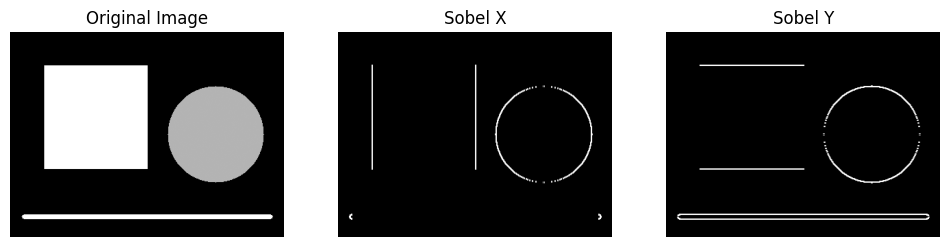

In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Create a sample image directly
img = np.zeros((300, 400), dtype=np.uint8)

# Add some simple shapes
cv2.rectangle(img, (50, 50), (200, 200), 255, -1)
cv2.circle(img, (300, 150), 70, 180, -1)
cv2.line(img, (20, 270), (380, 270), 255, 5)

# Sobel X and Y
sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

# Convert results to displayable images
sobel_x = cv2.convertScaleAbs(sobel_x)
sobel_y = cv2.convertScaleAbs(sobel_y)

# Display results
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(sobel_x, cmap="gray")
plt.title("Sobel X")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(sobel_y, cmap="gray")
plt.title("Sobel Y")
plt.axis("off")

plt.show()

In [28]:
#Q4 Task 2
import tensorflow as tf
import numpy as np

np.random.seed(42)

input_matrix = np.random.randint(
    0,
    10,
    size=(4, 4)
).astype(np.float32)

print("Original Matrix:")
print(input_matrix)

Original Matrix:
[[6. 3. 7. 4.]
 [6. 9. 2. 6.]
 [7. 4. 3. 7.]
 [7. 2. 5. 4.]]


In [29]:
input_tensor = input_matrix.reshape(
    1, 4, 4, 1
)

max_pooling = tf.keras.layers.MaxPooling2D(
    pool_size=(2, 2),
    strides=2
)

average_pooling = tf.keras.layers.AveragePooling2D(
    pool_size=(2, 2),
    strides=2
)

max_result = max_pooling(
    input_tensor
).numpy().squeeze()

average_result = average_pooling(
    input_tensor
).numpy().squeeze()

In [30]:
print("Original Matrix:")
print(input_matrix)

print("\nMax Pooled Matrix:")
print(max_result)

print("\nAverage Pooled Matrix:")
print(average_result)

Original Matrix:
[[6. 3. 7. 4.]
 [6. 9. 2. 6.]
 [7. 4. 3. 7.]
 [7. 2. 5. 4.]]

Max Pooled Matrix:
[[9. 7.]
 [7. 7.]]

Average Pooled Matrix:
[[6.   4.75]
 [5.   4.75]]


In [31]:
#Q5 Alex Net and ResNet
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import models

In [32]:
alexnet = models.Sequential(
    name="Simplified_AlexNet"
)

alexnet.add(
    layers.Input(
        shape=(224, 224, 3)
    )
)

# First convolution
alexnet.add(
    layers.Conv2D(
        96,
        (11, 11),
        strides=4,
        activation="relu"
    )
)

# First pooling
alexnet.add(
    layers.MaxPooling2D(
        pool_size=(3, 3),
        strides=2
    )
)

# Second convolution
alexnet.add(
    layers.Conv2D(
        256,
        (5, 5),
        activation="relu"
    )
)

# Second pooling
alexnet.add(
    layers.MaxPooling2D(
        pool_size=(3, 3),
        strides=2
    )
)

# Three convolution layers
alexnet.add(
    layers.Conv2D(
        384,
        (3, 3),
        activation="relu"
    )
)

alexnet.add(
    layers.Conv2D(
        384,
        (3, 3),
        activation="relu"
    )
)

alexnet.add(
    layers.Conv2D(
        256,
        (3, 3),
        activation="relu"
    )
)

# Third pooling
alexnet.add(
    layers.MaxPooling2D(
        pool_size=(3, 3),
        strides=2
    )
)

# Fully connected layers
alexnet.add(
    layers.Flatten()
)

alexnet.add(
    layers.Dense(
        4096,
        activation="relu"
    )
)

alexnet.add(
    layers.Dropout(0.5)
)

alexnet.add(
    layers.Dense(
        4096,
        activation="relu"
    )
)

alexnet.add(
    layers.Dropout(0.5)
)

# Output
alexnet.add(
    layers.Dense(
        10,
        activation="softmax"
    )
)

In [33]:
alexnet.summary()

Model: "Simplified_AlexNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 22, 22, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 6, 6, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 1, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4096)           │     1,052,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,622,154 (82.48 MB)

 Trainable params: 21,622,154 (82.48 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
#Task 2
def residual_block(
    input_tensor,
    filters=64
):

    # First convolution
    x = layers.Conv2D(
        filters,
        (3, 3),
        padding="same",
        activation="relu"
    )(input_tensor)

    # Second convolution
    x = layers.Conv2D(
        filters,
        (3, 3),
        padding="same",
        activation="relu"
    )(x)

    # Skip connection
    x = layers.Add()([
        input_tensor,
        x
    ])

    # Activation after addition
    x = layers.Activation(
        "relu"
    )(x)

    return x

In [35]:
inputs = layers.Input(
    shape=(64, 64, 3)
)

# Initial 7x7 convolution
x = layers.Conv2D(
    64,
    (7, 7),
    strides=2,
    padding="same"
)(inputs)

x = layers.Activation("relu")(x)

# First residual block
x = residual_block(
    x,
    filters=64
)

# Second residual block
x = residual_block(
    x,
    filters=64
)

# Fully connected section
x = layers.Flatten()(x)

x = layers.Dense(
    128,
    activation="relu"
)(x)

outputs = layers.Dense(
    10,
    activation="softmax"
)(x)

resnet_model = models.Model(
    inputs=inputs,
    outputs=outputs,
    name="Simple_ResNet"
)

In [36]:
resnet_model.summary()

Model: "Simple_ResNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │      9,472 │ input_layer_3[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │     36,928 │ conv2d_6[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 32,    │          0 │ activation[0][0], │
│                     │ 64)               │            │ conv2d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 32, 32,    │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 32, 32,    │     36,928 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 32, 32,    │     36,928 │ conv2d_8[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 32, 32,    │          0 │ activation_1[0][… │
│                     │ 64)               │            │ conv2d_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 32, 32,    │          0 │ add_1[0][0]       │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 65536)     │          0 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 128)       │  8,388,736 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 10)        │      1,290 │ dense_5[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,547,210 (32.61 MB)

 Trainable params: 8,547,210 (32.61 MB)

 Non-trainable params: 0 (0.00 B)